# 0. DATA LOADING AND INITIAL OVERVIEW


In [1]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('/content/marketing_campaign.csv', sep=';')
df.columns = df.columns.str.strip()

print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== SHAPE ===")
print(df.shape)

print("\n=== COLUMN INFO ===")
print(df.info())

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())


=== FIRST 5 ROWS ===
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Compla

# 1. DATA CLEANING


In [3]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(df.columns)
df.columns = df.columns.str.strip()


=== MISSING VALUES ===
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProduc

In [4]:
df['Income'].fillna(df['Income'].median(), inplace=True)

/tmp/ipykernel_23378/1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [7]:
print("\n✅ Cleaning complete. Row count:", len(df))


✅ Cleaning complete. Row count: 2240


# 2. DESCRIPTIVE ANALYSIS — "Who are the customers?"


In [8]:
# 2.1 Customer count by education level
print("\n--- Distribution by education level ---")

print(df['Education'].value_counts(normalize=True) * 100)


--- Distribution by education level ---
Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64


In [9]:
# 2.2 Distribution by marital status
print("\n--- Marital status distribution ---")

print(df['Marital_Status'].value_counts())


--- Marital status distribution ---
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [10]:
# 2.3 Average income by education level
print("\n--- Average income by education ---")
df_edu = (df.groupby('Education')['Income'].mean().reset_index().sort_values('Income', ascending=False))
print(df_edu)



--- Average income by education ---
    Education        Income
4         PhD  56096.303498
3      Master  52896.777027
2  Graduation  52707.305679
0    2n Cycle  47688.583744
1       Basic  20306.259259


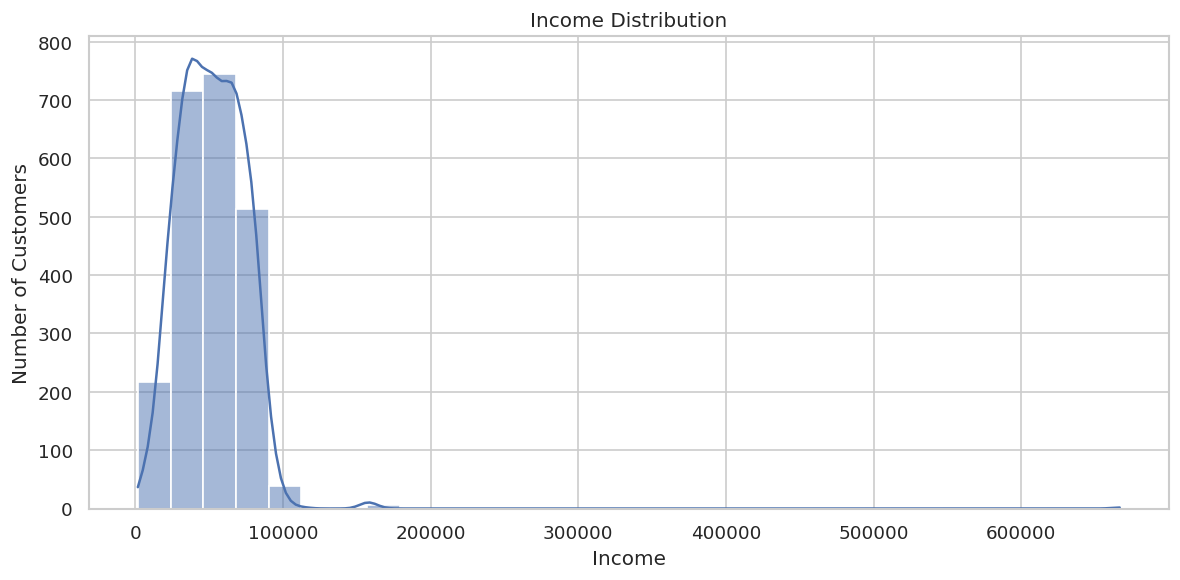

In [11]:
# 2.4 Visualization — Income distribution
# Histplot shows the distribution of income across customers
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['Income'], bins=30, kde=True, ax=ax)
ax.set_title('Income Distribution')
ax.set_xlabel('Income')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


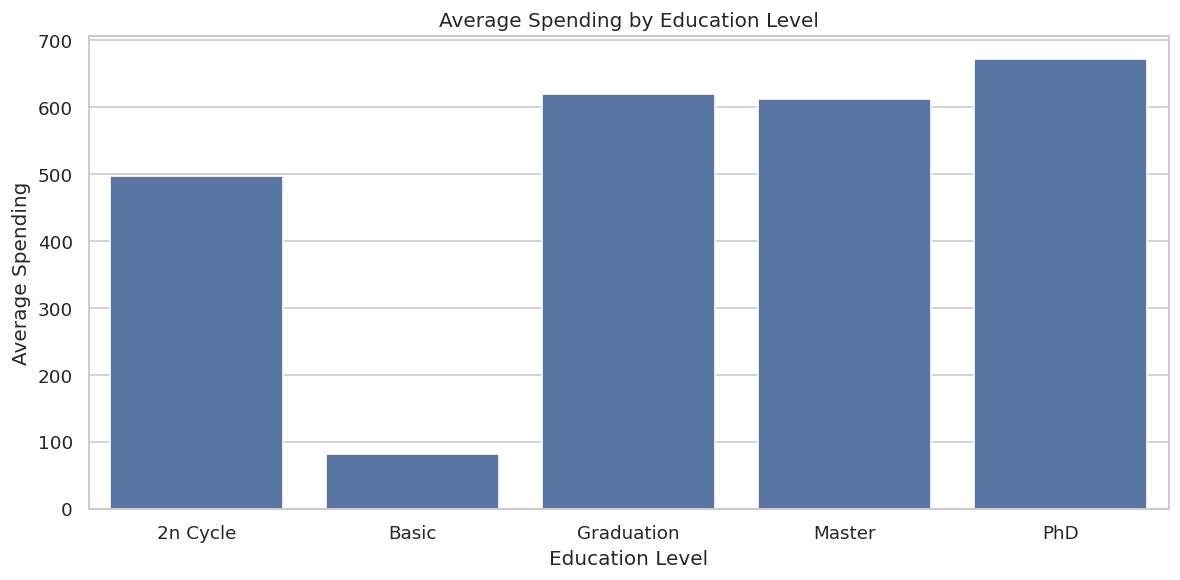

In [12]:
# 2.5 Visualization — Average spending by education
fig, ax = plt.subplots(figsize=(10, 5))

# Calculate average total spending per education group
df['MntTotal'] = (df['MntWines'] + df['MntFruits'] +
                  df['MntMeatProducts'] + df['MntFishProducts'] +
                  df['MntSweetProducts'] + df['MntGoldProds'])

df_edu_spent = df.groupby('Education')['MntTotal'].mean().reset_index()
sns.barplot(data=df_edu_spent, x='Education', y='MntTotal', ax=ax)
ax.set_title('Average Spending by Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Spending')
plt.tight_layout()
plt.show()


**Business Insight**
>Descriptive results:
>- Most customers earn between 40,000 and 60,000
>- Highest spending group: PhD-educated customers

# 3. DIAGNOSTIC ANALYSIS — "Why do some customers respond?"


In [13]:
# 3.1 Overall campaign response rate
print("\n--- Campaign response rate ---")
print(df['Response'].value_counts(normalize=True))


--- Campaign response rate ---
Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


In [14]:
# 3.2 Responders vs non-responders — income comparison
print("\n--- Average income by response ---")
print(df.groupby('Response')['Income'].mean().reset_index().sort_values('Income', ascending=False))


--- Average income by response ---
   Response        Income
1         1  60183.244012
0         0  50845.677597


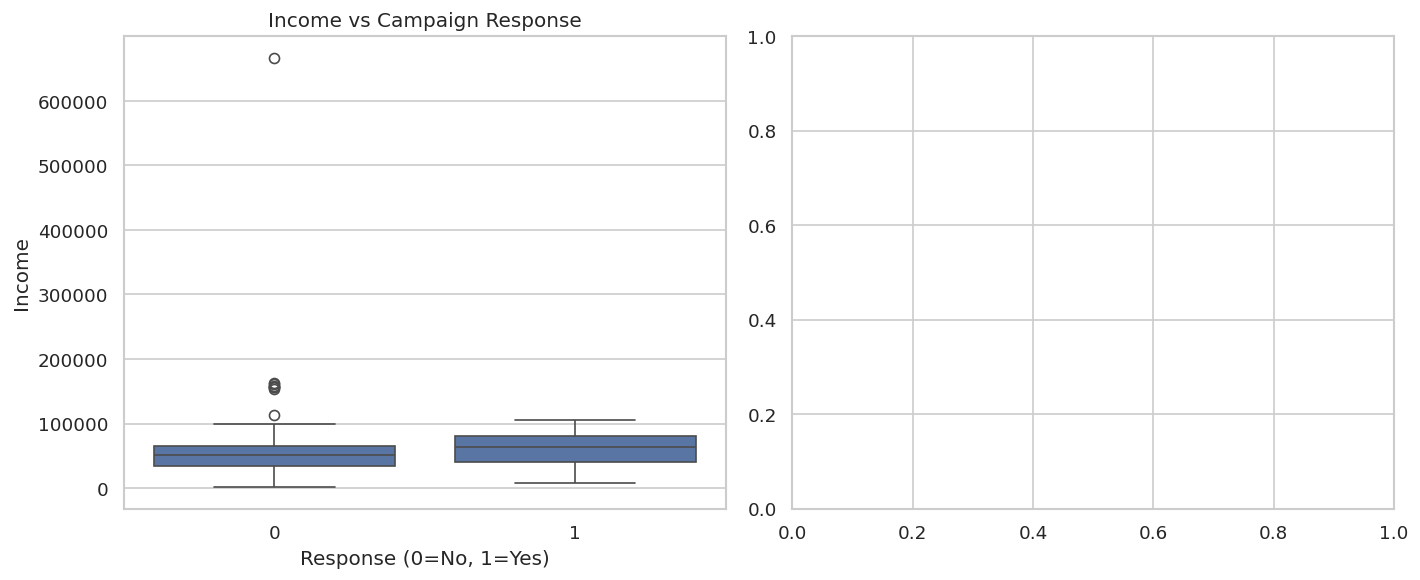

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Response', y='Income', ax=axes[0])
axes[0].set_title('Income vs Campaign Response')
axes[0].set_xlabel('Response (0=No, 1=Yes)')
axes[0].set_ylabel('Income')
plt.tight_layout()
plt.show()

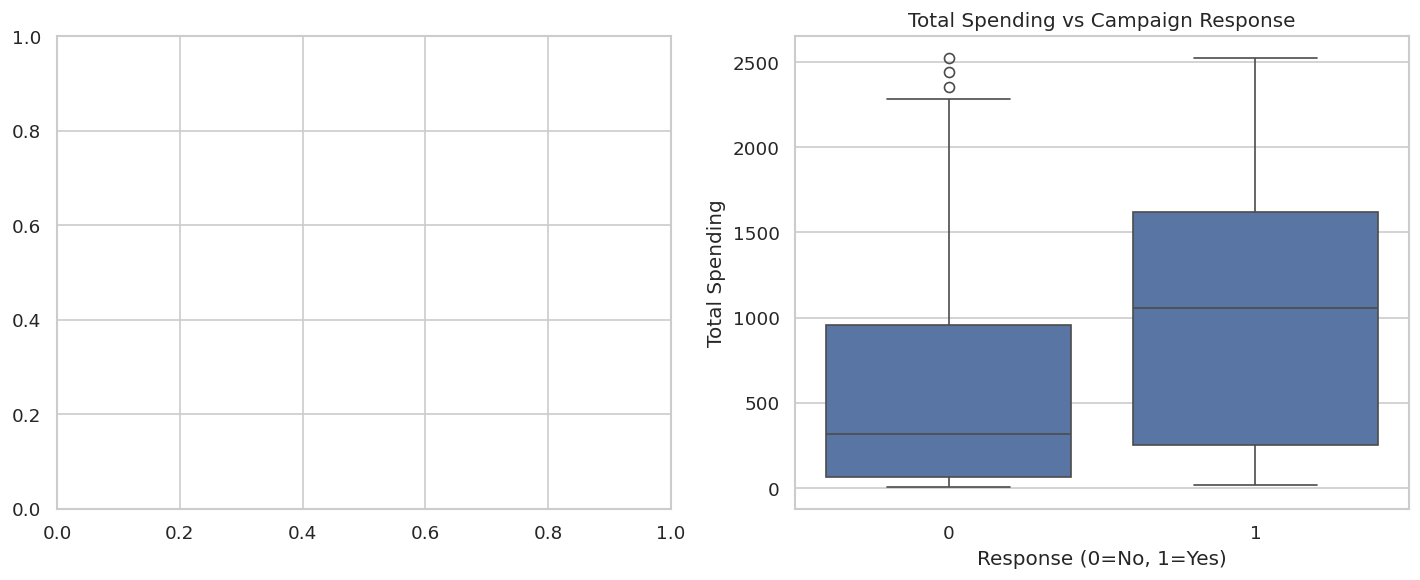

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Response', y='MntTotal', ax=axes[1])
axes[1].set_title('Total Spending vs Campaign Response')
axes[1].set_xlabel('Response (0=No, 1=Yes)')
axes[1].set_ylabel('Total Spending')

plt.tight_layout()
plt.show()

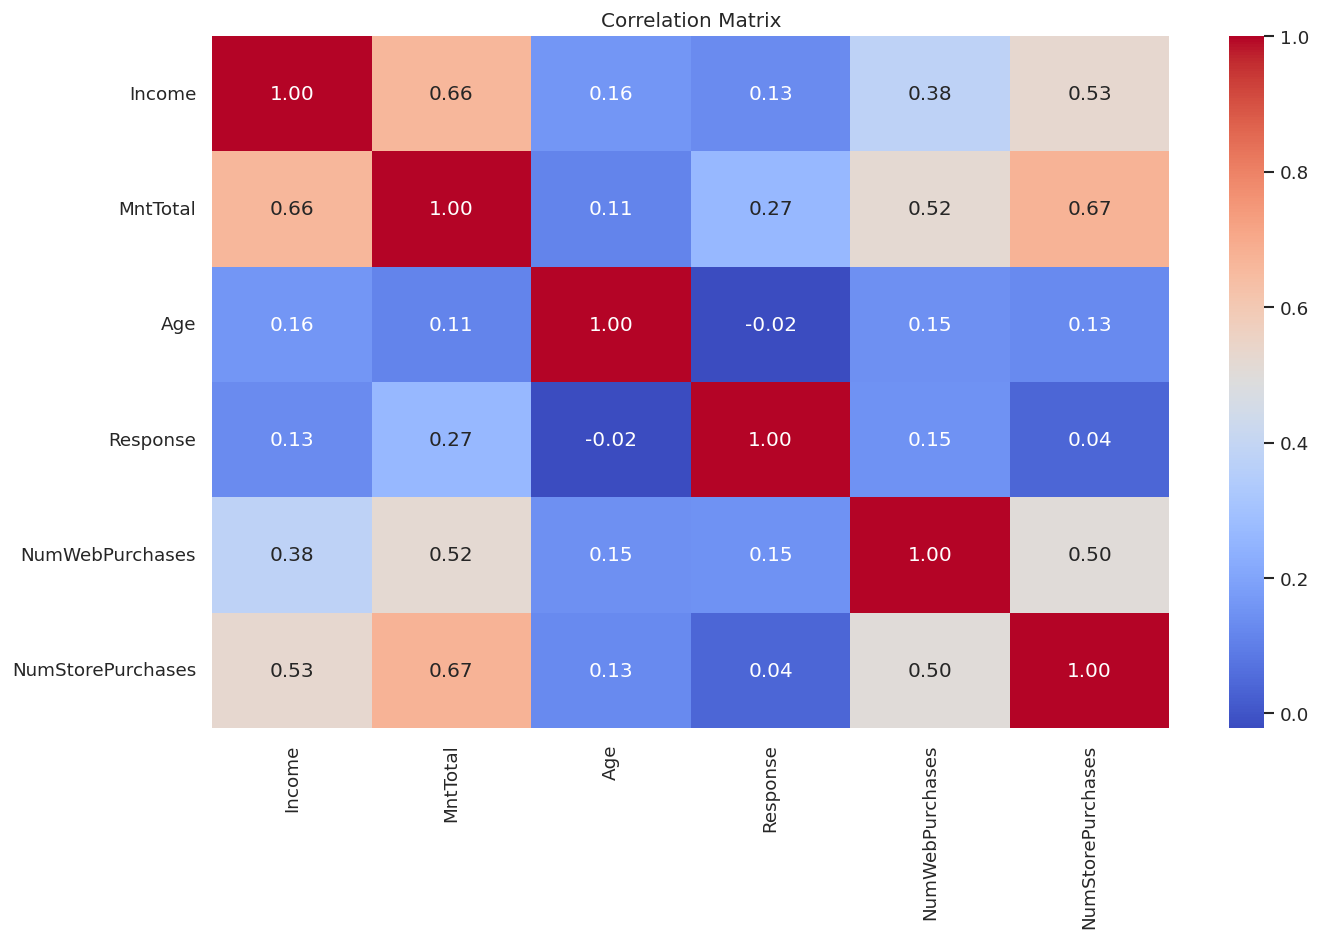

In [17]:
# 3.4 Correlation matrix
# Heatmap shows correlations between all numeric columns at once
# +1 = strong positive correlation, -1 = strong negative correlation
from datetime import datetime

df['Age'] = datetime.now().year - df['Year_Birth']

fig, ax = plt.subplots(figsize=(12, 8))
cols = ['Income', 'MntTotal', 'Age', 'Response',
        'NumWebPurchases', 'NumStorePurchases']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


**Business Insight**
>Diagnostic results:
>- Responder profile: Higher-income customers are more likely to respond to campaigns. However, income alone is not the only factor — there are high-income non-responders (outliers). Responders show significantly higher median spending and more active purchasing behaviour. Among non-responders, while some have high spending, the majority spend little. Overall, the higher a customer's spending, the more likely they are to respond to a campaign.
>- Strongest correlations identified: Response vs MntTotal = 0.66, meaning higher spending increases campaign response probability. MntTotal vs NumStorePurchases = 0.67, indicating active in-store buyers spend more overall. MntTotal vs NumWebPurchases also shows a meaningful relationship — online purchases contribute to total spending.

# 4. PREDICTIVE ANALYSIS — "What is the spending trend?"


In [18]:
# Extract date columns
df['year']  = df['Dt_Customer'].dt.year
df['month'] = df['Dt_Customer'].dt.month

In [19]:
monthly = df.groupby(['year', 'month'])['MntTotal'].sum().reset_index()

In [20]:
monthly['rolling_3m'] = monthly['MntTotal'].rolling(3).mean()

In [21]:
monthly['cumulative'] = monthly['MntTotal'].cumsum()

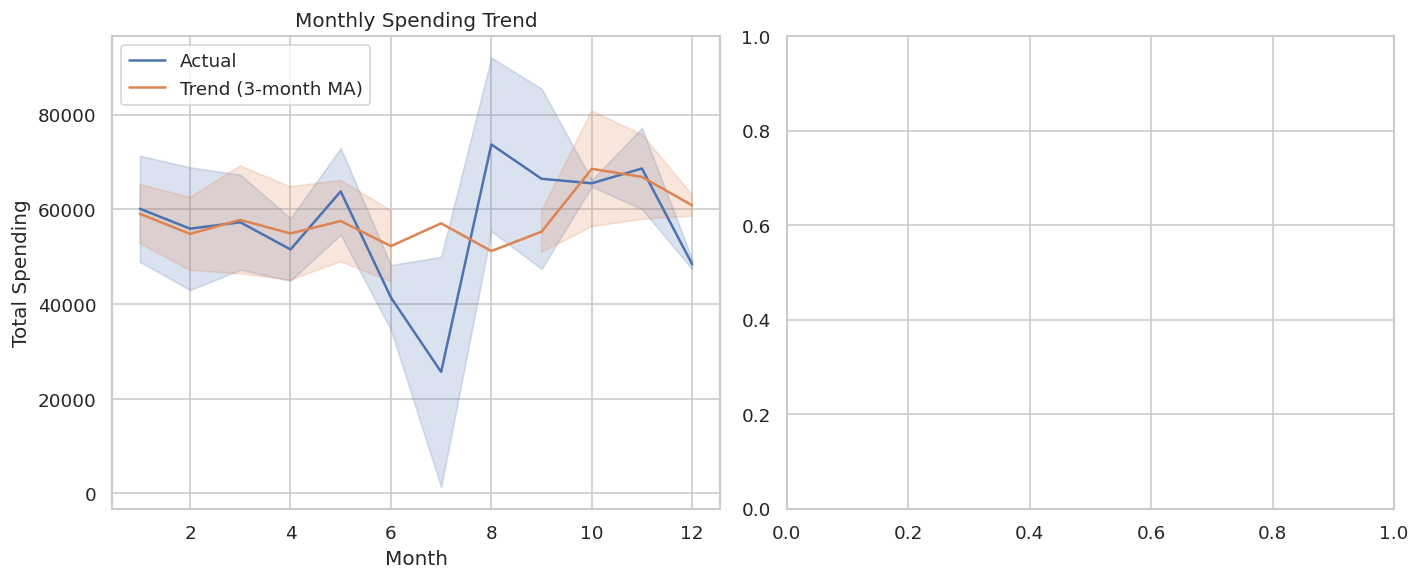

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(data=monthly, x='month', y='MntTotal',
             label='Actual', ax=axes[0])
sns.lineplot(data=monthly, x='month', y='rolling_3m',
             label='Trend (3-month MA)', ax=axes[0])
axes[0].set_title('Monthly Spending Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Spending')
plt.tight_layout()
plt.show()

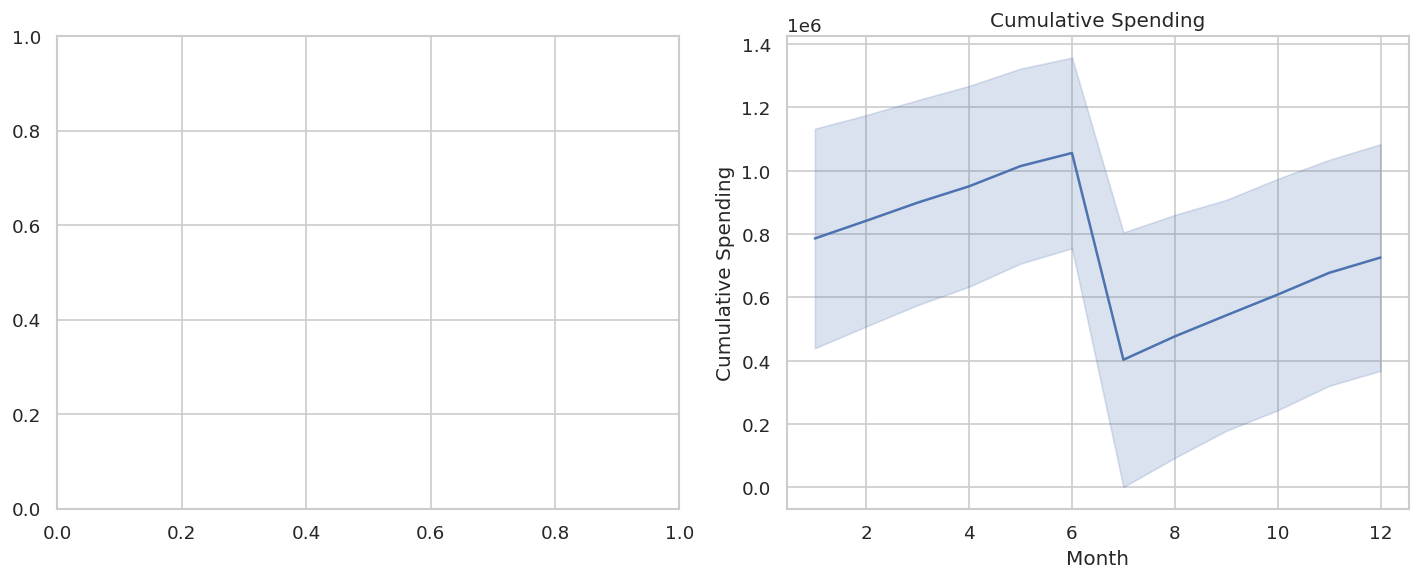

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(data=monthly, x='month', y='cumulative', ax=axes[1])
axes[1].set_title('Cumulative Spending')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cumulative Spending')

plt.tight_layout()
plt.show()

**Business Insight**
>Predictive results:
>- Overall trend: Spending remained stable between 55,000–65,000 in the first 6 months. A sharp drop occurred in month 7, likely a seasonal dip or anomaly. From month 8 to 12, spending recovered and grew to the 65,000–70,000 range.
>- Most active month: Spending peaks in August (month 8). Month 6 also stands out as the highest point before the mid-year dip.

# 5. PRESCRIPTIVE ANALYSIS — "What should we do?"


In [24]:
# 5.1 Analysis by purchase channel
print("\n--- Average purchases by channel ---")
channels = ['NumWebPurchases', 'NumCatalogPurchases',
            'NumStorePurchases', 'NumDealsPurchases']
# Calculate average purchases per channel for campaign responders
responders = df[df['Response'] == 1]
print(responders[channels].mean().sort_values(ascending=False))



--- Average purchases by channel ---
NumStorePurchases      6.095808
NumWebPurchases        5.071856
NumCatalogPurchases    4.203593
NumDealsPurchases      2.335329
dtype: float64


In [25]:
# 5.2 "Ideal customer" profile
print("\n--- Responder customer profile ---")
print(responders[['Age','Income', 'MntTotal']].mean())


--- Responder customer profile ---
Age            56.583832
Income      60183.244012
MntTotal      987.392216
dtype: float64


Text(0.5, 0.98, 'Marketing Campaign — Final Dashboard')

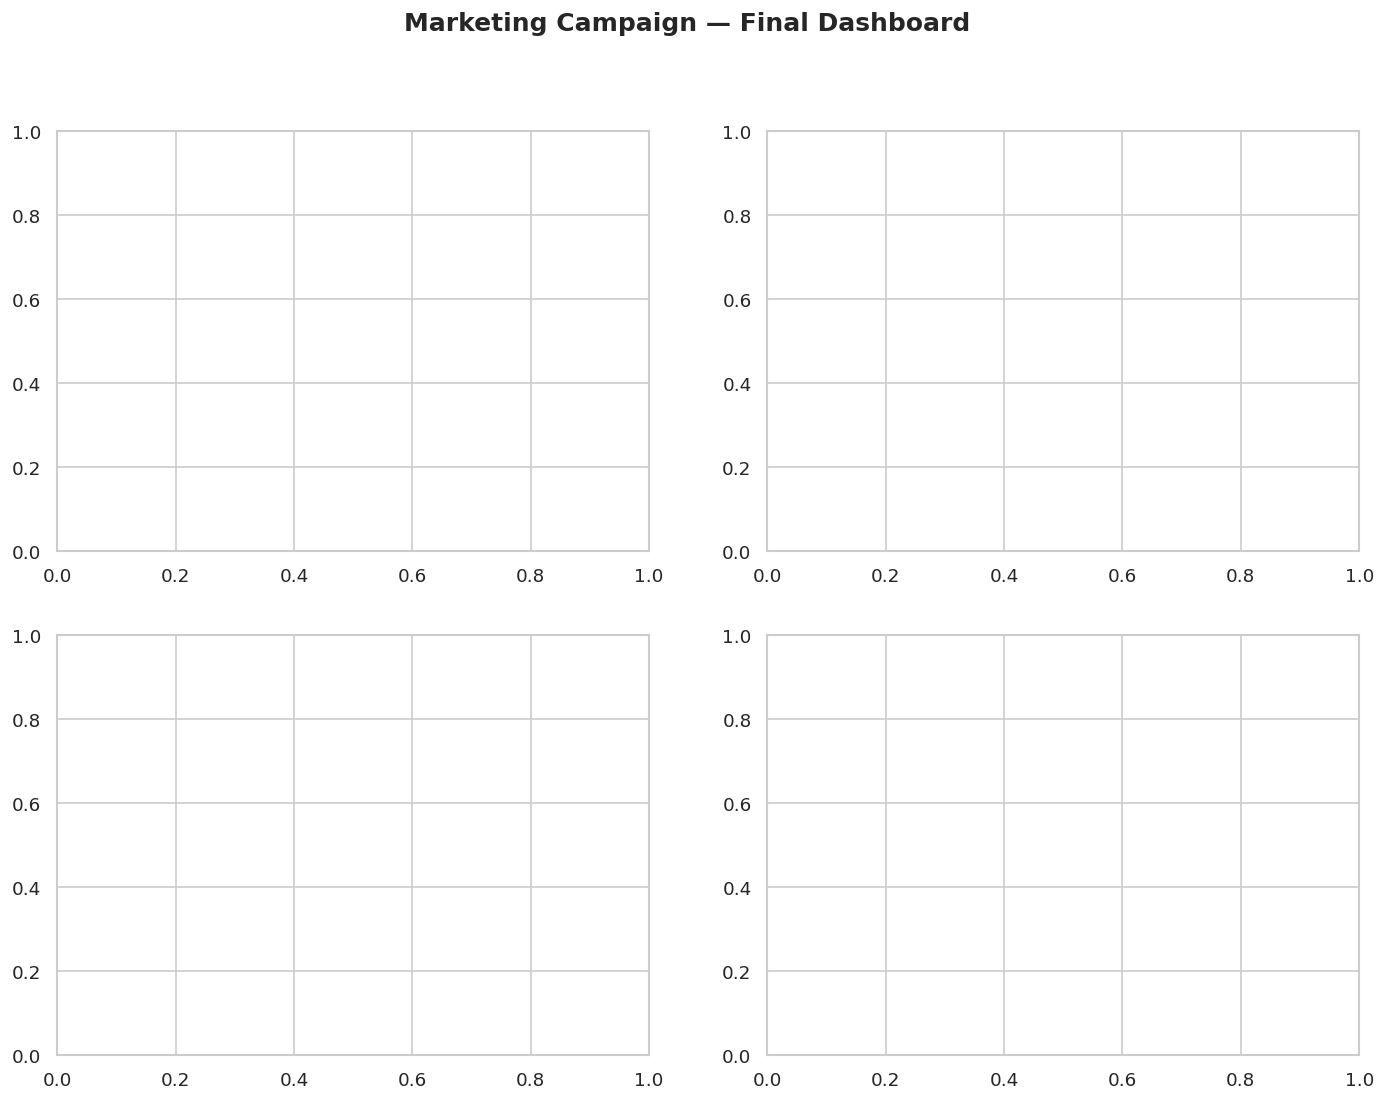

In [26]:
# 5.3 Final dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Marketing Campaign — Final Dashboard', fontsize=15, fontweight='bold')

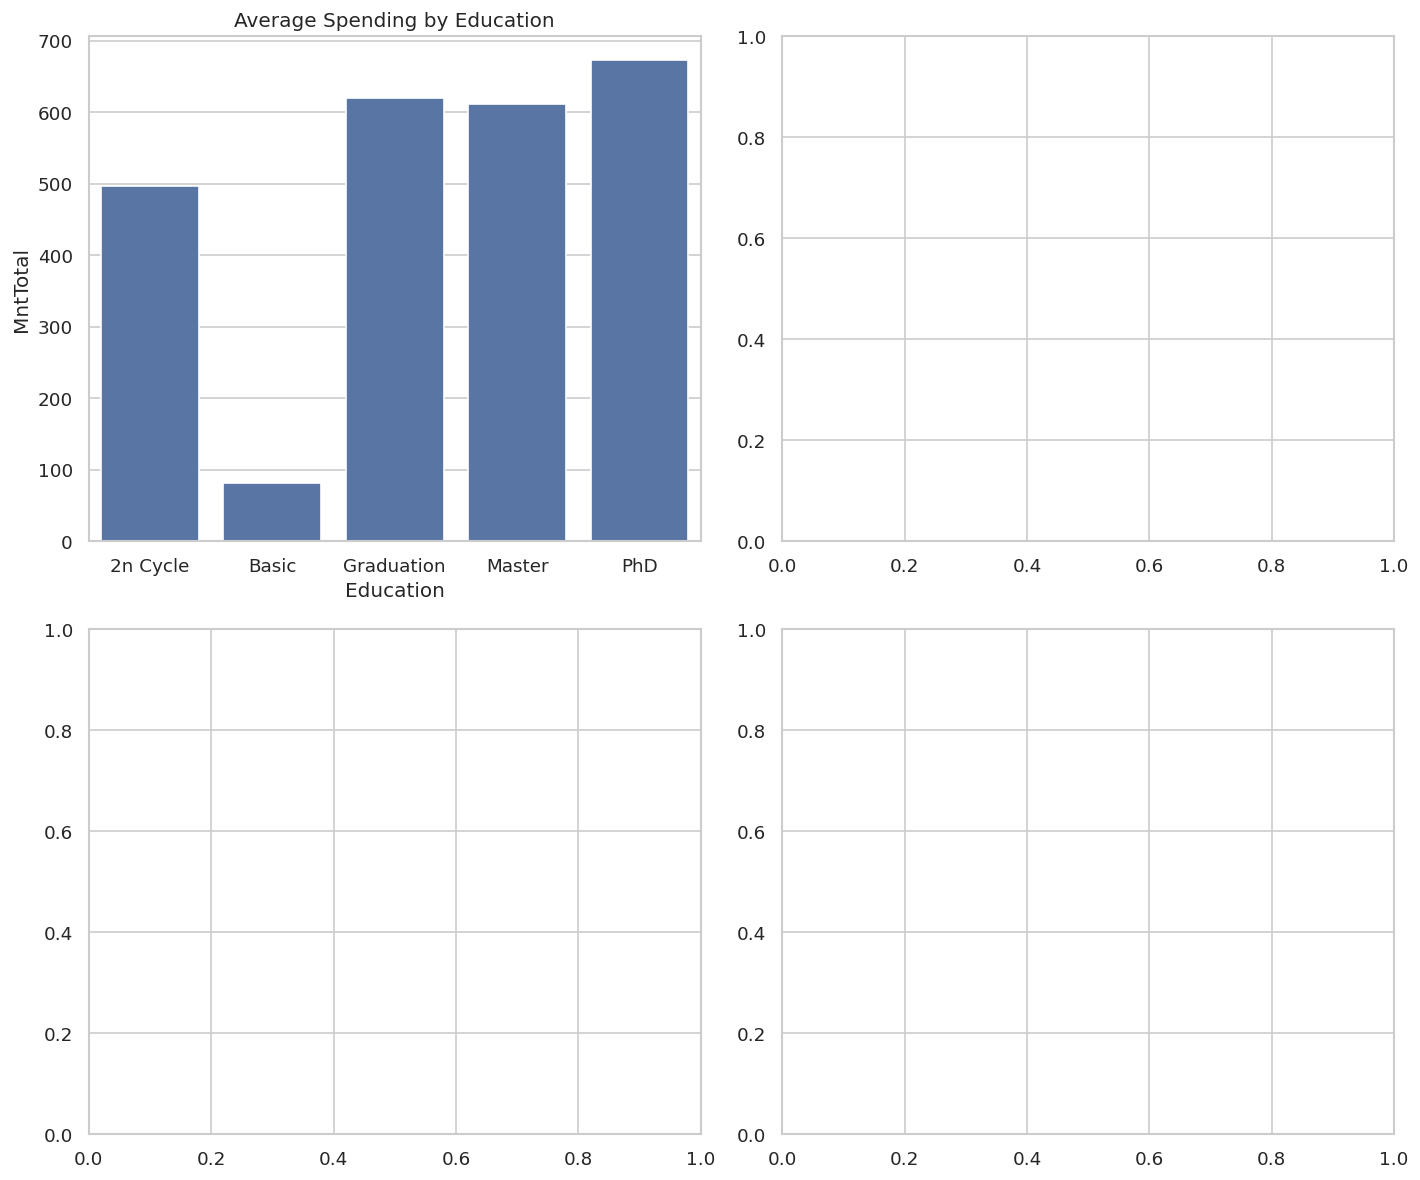

In [27]:
# Chart 1: Spending by education
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df_edu_spent = df.groupby('Education')['MntTotal'].mean().reset_index()
sns.barplot(data=df_edu_spent, x='Education', y='MntTotal', ax=axes[0,0])
axes[0,0].set_title('Average Spending by Education')
plt.tight_layout()
plt.show()

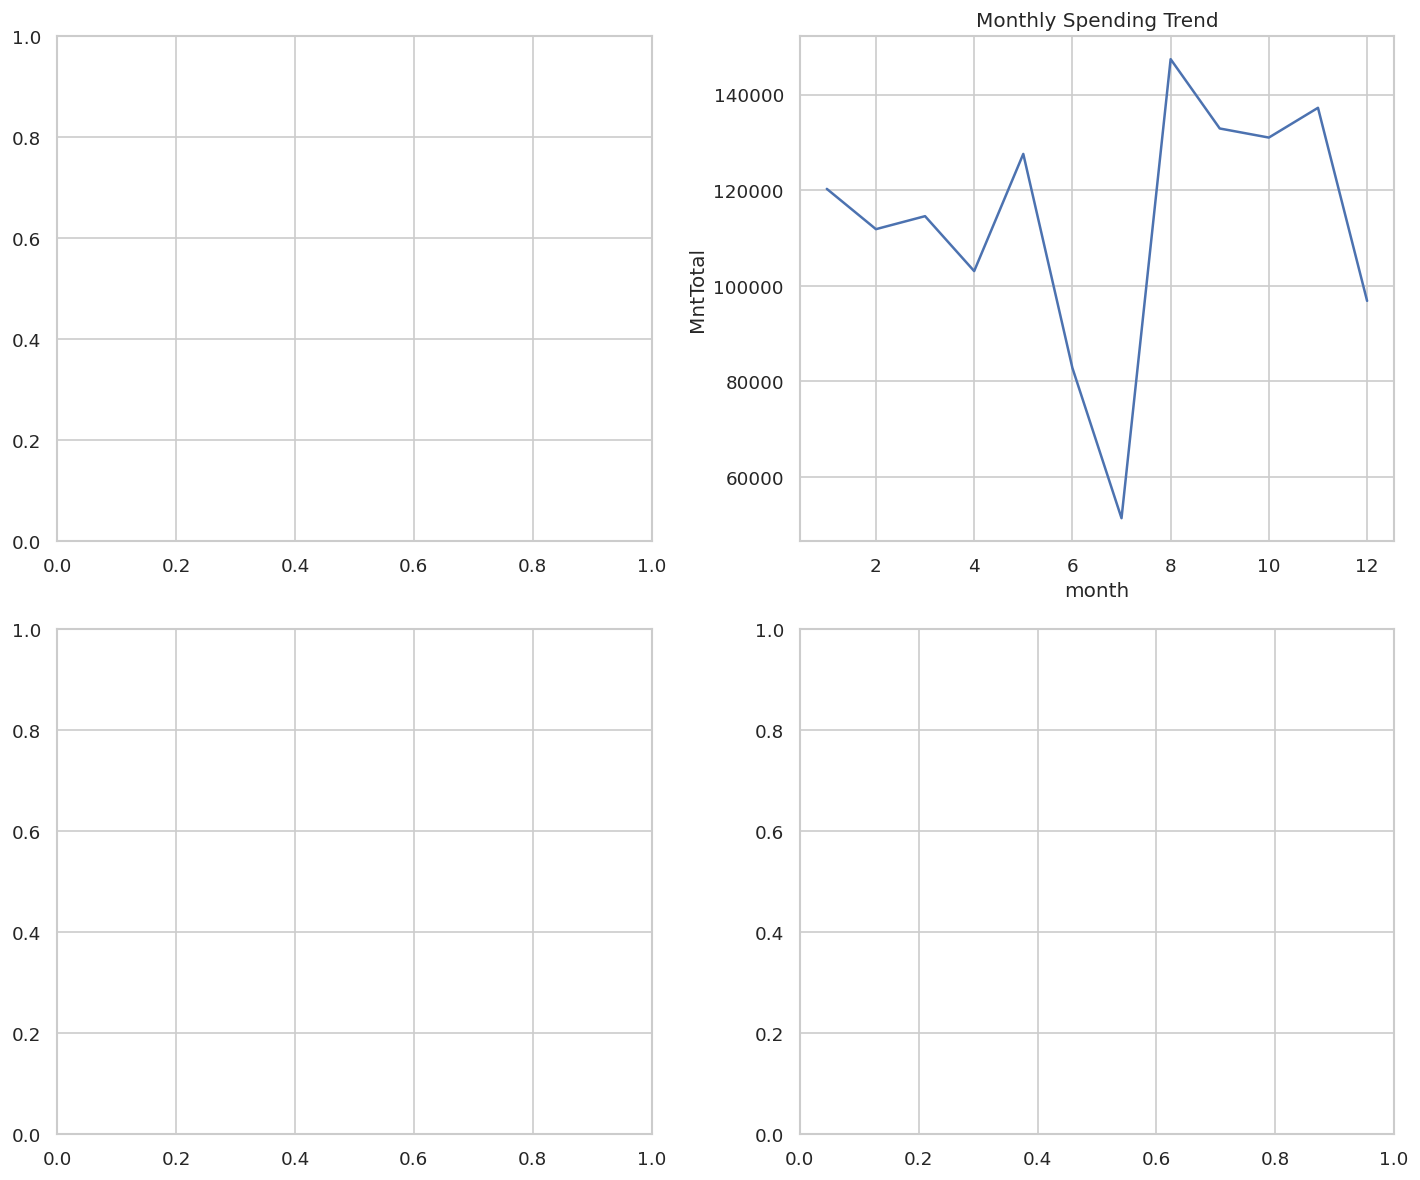

In [28]:
# Chart 2: Spending trend
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

monthly = df.groupby('month')['MntTotal'].sum().reset_index()

sns.lineplot(data=monthly, x='month', y='MntTotal', ax=axes[0,1])
axes[0,1].set_title('Monthly Spending Trend')
plt.tight_layout()
plt.show()

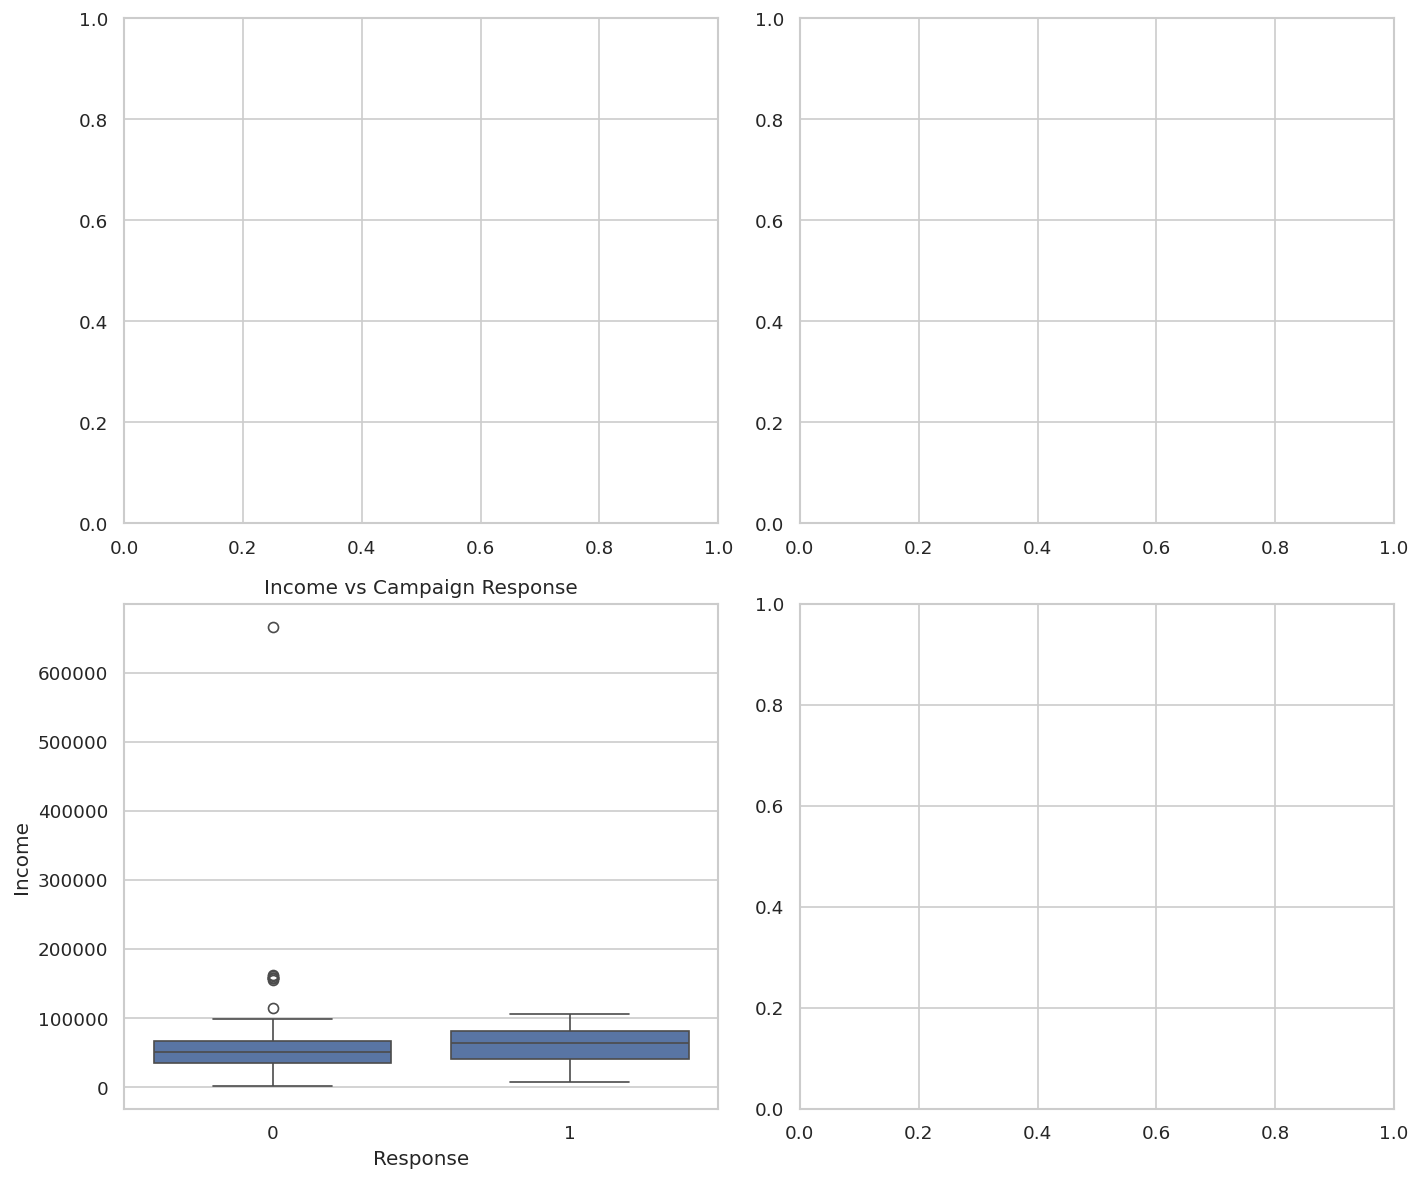

In [29]:
# Chart 3: Income vs Response
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=df, x='Response', y='Income', ax=axes[1,0])
axes[1,0].set_title('Income vs Campaign Response')
plt.tight_layout()
plt.show()

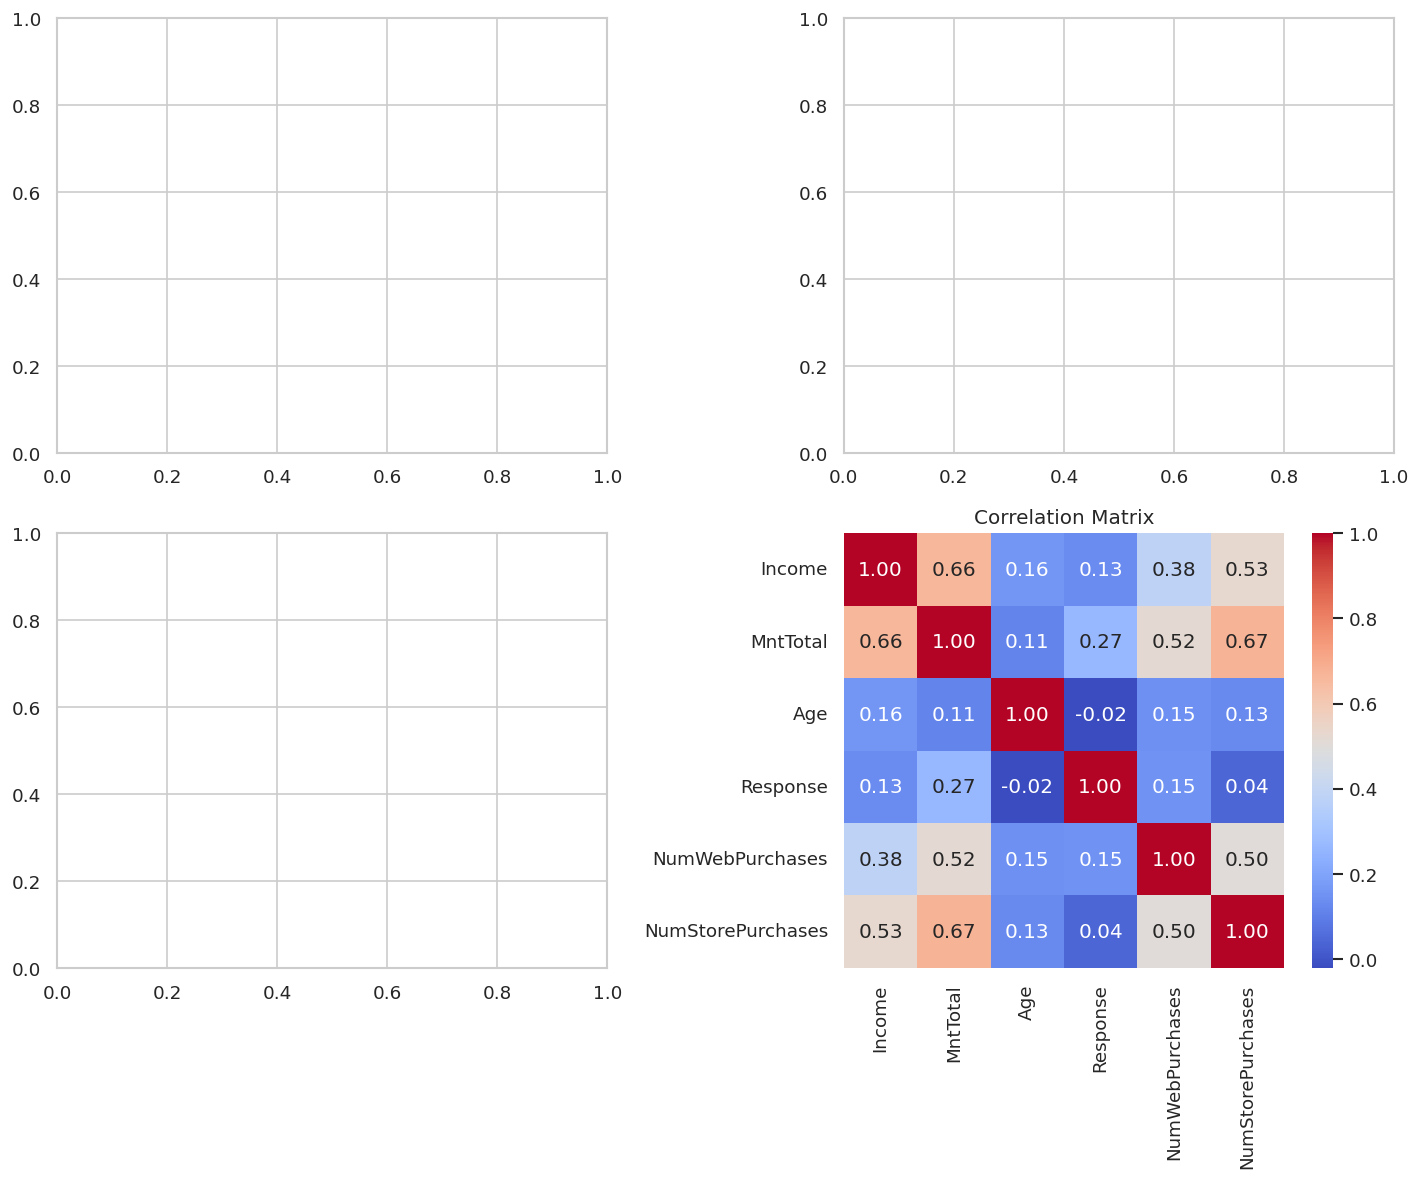

In [30]:
# Chart 4: Correlation heatmap
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# 6. FINAL RECOMMENDATIONS


>BUSINESS RECOMMENDATIONS
>1. Target audience: Well-educated, middle-to-high income customers. They respond well to campaigns and generate higher spending.
>2. Most effective channel: Online buyers show a moderate correlation with spending (0.52), while in-store buyers show a strong correlation (0.67). High-income customers also visit stores more frequently (0.53). The offline store is the primary channel, but combining it with online is recommended.
>3. Most active period: August shows the absolute spending peak; months 10–11 also show consistently high activity.
>4. Recommendations: Use the responder profile as the targeting baseline. Offer personalised deals to high-income customers. Promote premium products to PhD-educated customers. Improve the offline store experience. Launch the main campaign in August. Run discount promotions in months 7 and 12 to counter the seasonal dip.     